In [1]:

import os
import glob
import scipy as sp
import numpy as np
import math as m
import matplotlib.pyplot as plt
import pandas as pd
from distributed.stealing import fast_tasks
from scipy import optimize
from matplotlib.colors import LogNorm
from astropy.io import fits
from astropy import units as u
from scipy.optimize import curve_fit
import emcee
import corner
from IPython.display import display, Math
from scipy.integrate import quad
import multiprocessing
import NPDF_MLE_func as MLE


In [2]:

'''
README

>>> step 1: collect all NH2 file in a directory ("./NH2/" in this example), assign this path to the variable “NH2path”. each NH2 file name should start with "sourcename_", e.g. "SgrB2m_NH2.fits".
>>> step 2: run cell 4 with fit == False, have a look at N-PDFs of each cloud firstly.
>>> step 3: set up fitting parameters in "NPDF_MLE_para.xlsx", the "source" column should match the sourcename in the NH2 file. N0_fit, N1_fit are the choosed fitting range in log10(NH2). Ncutoff gives the lowest threshold to show the N-PDF. xlim, ylim are used to control the show of the N-PDF if specified. If you want to limit the fitting process, tp0 gives the center point of the transition point limitation, tp1 gives the half width of the limitation interval.
>>> step 4: run ! (sampling, run !)

notes:
1. If you meet the error "The chain is shorter than 50 times the integrated autocorrelation time ...", run more step in mcmc.
2. If you only want to fit a powerlaw tail, change to model = "PL", and write the Nthres in "Nthres_fit_MLE_para.xlsx" manually.
3. Set model = "LN" for only lognormal fit.
4. If you want to re-run any source, delete the corresponding ".npy" file in ./MCMCpara/ and run the fitting cell again.


N-PDF fitting code (MLE + MCMC) by Linjing Feng. Last updated: 2025.12.22.
Thanks to Yaojun Xiao for help with code testing and improvements.
'''


'\nREADME\n\n>>> step 1: collect all NH2 file in a directory ("./NH2/" in this example), assign this path to the variable “NH2path”. each NH2 file name should start with "sourcename_", e.g. "SgrB2m_NH2.fits".\n>>> step 2: run cell 4 with fit == False, have a look at N-PDFs of each cloud firstly.\n>>> step 3: set up fitting parameters in "NPDF_MLE_para.xlsx", the "source" column should match the sourcename in the NH2 file. N0_fit, N1_fit are the choosed fitting range in log10(NH2). Ncutoff gives the lowest threshold to show the N-PDF. xlim, ylim are used to control the show of the N-PDF if specified. If you want to limit the fitting process, tp0 gives the center point of the transition point limitation, tp1 gives the half width of the limitation interval.\n>>> step 4: run ! (sampling, run !)\n\nnotes:\n1. If you meet the error "The chain is shorter than 50 times the integrated autocorrelation time ...", run more step in mcmc.\n2. If you only want to fit a powerlaw tail, change to model 

In [3]:

def npdf_fit(sourcename,data,Nrange, mcmcstep = 1500, tplimit = None,sigmalimit = [0.05,0.5], mulimit = 0.05,tp_prior = None, model = "LNPL"):

    # read parameter
    N0 = Nrange[0]
    N1 = Nrange[1]

    # preprocess
    data_1D = data.copy().ravel()
    data_1D[data_1D <= 10**N0] = np.nan
    data_1D[data_1D > 10**N1] = np.nan
    data_1D = data_1D[~np.isnan(data_1D)]
    data_1D = data_1D[~np.isinf(data_1D)]
    data_1D = np.log10(data_1D)
    den, bin = MLE.npdf_show(sourcename,10**data_1D,show = False)

    # run mcmc
    if model == "LNPL":
        mu = bin[np.where(den == den.max())[0]][0]
        if tplimit is None:
            tpinitial = mu+0.3
        else:
            tpinitial = tplimit[0]
        initial = np.array([mu,sigmalimit[0]+0.01,tpinitial,-2.])
        pos = initial + 10**-3 * np.random.randn(16, 4)
        nwalkers, ndim = pos.shape
        labels = [r"$\mu$",r"$\sigma$",r"${\rm lg}(N_{\rm threshold})$",r"$\alpha$"]
        print(f"{sourcename} npdf fit:\nmcmcstep: {mcmcstep}\ndatalength: {len(data_1D):.2e}")
        with multiprocessing.Pool() as pool:
            sampler = emcee.EnsembleSampler(
                nwalkers, ndim, MLE.log_probability,moves=[
                    (emcee.moves.DEMove(), 0.8),(emcee.moves.DESnookerMove(), 0.2),
                ], args=(data_1D, initial, tplimit, sigmalimit, mulimit, tp_prior), pool = pool
            )
            sampler.run_mcmc(pos,mcmcstep, progress=False)

    elif model == "LN":
        mu = bin[np.where(den == den.max())[0]][0]
        initial = np.array([mu,sigmalimit[0]+0.01])
        pos = initial + 10**-3 * np.random.randn(16, 2)
        nwalkers, ndim = pos.shape
        labels = [r"$\mu$",r"$\sigma$"]
        print(f"{sourcename} npdf fit:\nmcmcstep: {mcmcstep}\ndatalength: {len(data_1D):.2e}")
        with multiprocessing.Pool() as pool:
            sampler = emcee.EnsembleSampler(
                nwalkers, ndim, MLE.log_probability_LN,moves=[
                    (emcee.moves.DEMove(), 0.8),(emcee.moves.DESnookerMove(), 0.2),
                ], args=(data_1D, initial, sigmalimit, mulimit), pool = pool
            )
            sampler.run_mcmc(pos,mcmcstep, progress=False)

    elif model == "PL":
        tp = bin[0]
        ptp = den[0]
        initial = np.array([-2])
        pos = initial + 10**-3 * np.random.randn(16, 1)
        nwalkers, ndim = pos.shape
        labels = [r"$\alpha$"]
        print(f"{sourcename} npdf fit:\nmcmcstep: {mcmcstep}\ndatalength: {len(data_1D):.2e}")
        with multiprocessing.Pool() as pool:
            sampler = emcee.EnsembleSampler(
                nwalkers, ndim, MLE.log_probability_PL,moves=[
                    (emcee.moves.DEMove(), 0.8),(emcee.moves.DESnookerMove(), 0.2),
                ], args=(data_1D, initial, tp, ptp), pool = pool
            )
            sampler.run_mcmc(pos,mcmcstep, progress=False)

    # show mcmc sampling progress
    fig, axes = plt.subplots(ndim, figsize=(10, 7), sharex=True)
    samples = sampler.get_chain()
    print(samples.shape)
    for i in range(ndim):
        if ndim == 1:
            ax = axes
            ax1 = axes
        else:
            ax = axes[i]
            ax1 = axes[-1]
        ax.plot(samples[:, :, i], "k", alpha=0.3)
        ax.set_xlim(0, len(samples))
        ax.set_ylabel(labels[i])
        ax.yaxis.set_label_coords(-0.1, 0.5)
    ax1.set_xlabel("step number")
    Tau = sampler.get_autocorr_time()
    print(Tau)

    flat_samples = sampler.get_chain(discard=500, thin=15, flat=True)

    mcmcpara = np.zeros([ndim,3])
    errorsigma = 1
    for i in range(ndim):
        if errorsigma == 1:
            mcmc = np.percentile(flat_samples[:, i], [16, 50, 84])
            quantiles = [0.16, 0.5, 0.84]
        elif errorsigma == 2:
            mcmc = np.percentile(flat_samples[:, i], [2.3, 50, 97.7])
            quantiles = [0.023, 0.5, 0.977]
        elif errorsigma == 3:
            mcmc = np.percentile(flat_samples[:, i], [0.13, 50, 99.87])
            quantiles = [0.013, 0.5, 0.9987]
        q = np.diff(mcmc)
        txt = "\mathrm{{{3}}} = {0:.3f}_{{-{1:.3f}}}^{{{2:.3f}}}"
        txt = txt.format(mcmc[1], q[0], q[1], labels[i])
        display(Math(txt))
        mcmcpara[i,0] = mcmc[1]
        mcmcpara[i,1] = -q[0]
        mcmcpara[i,2] = q[1]

    # show corner map
    plt.figure(facecolor='white',figsize = (7,5),dpi=120)
    fig = corner.corner(
        flat_samples, labels=labels,
        quantiles = quantiles,
        show_titles=True,
        title_kwargs={"fontsize":12},
        label_kwargs={'fontsize':18}
    )
    plt.show()
    if os.path.exists(f"./MCMCpara/") == False:
        os.mkdir(f"./MCMCpara/")
    np.save(f"./MCMCpara/{sourcename}_mcmcpara_{N0}_{N1}_{model}.npy",mcmcpara)    # mu, sigma, tp, index in axis 0
    if os.path.exists(f"./MCMCsamples/") == False:
        os.mkdir(f"./MCMCsamples/")
    np.save(f"./MCMCsamples/{sourcename}_mcmcsamples_{N0}_{N1}_{model}.npy",flat_samples)    # mu, sigma, tp, index in axis 0

    return mcmcpara


SgrB2


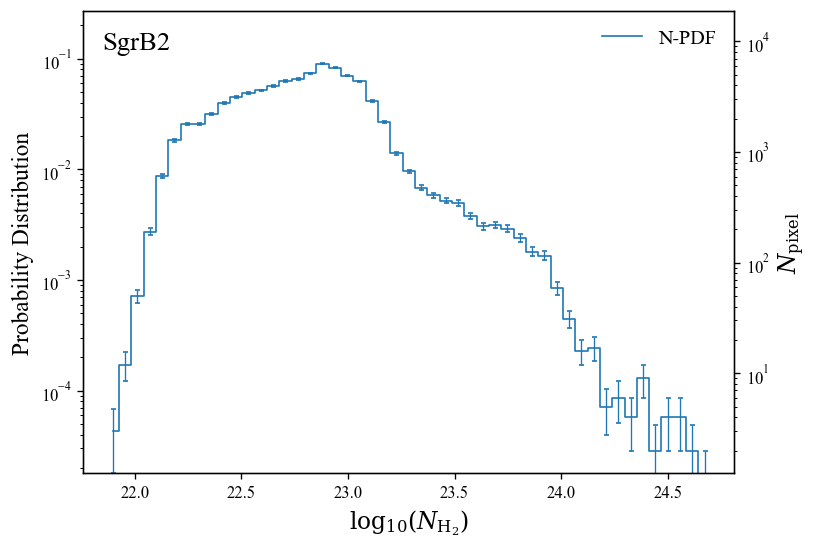

SgrB2  is done.


In [4]:

if __name__ == "__main__":

    ##### >>> input
    NH2path = "./NH2/"
    dfpath = "./NPDF_MLE_para.xlsx"
    showNPDF = True
    fit = False
    #####

    plt.rcParams["mathtext.fontset"] = "dejavuserif"
    plt.rcParams["font.family"] = "Times New Roman"

    pathlist = glob.glob(NH2path + "*.fits")

    df = pd.read_excel(dfpath)
    df.drop(columns = "Unnamed: 0")
    sourcenamelist = df.loc[:,"source"].values

    for sourcename in sourcenamelist:

        # read NH2 file & preprocess
        print(sourcename)
        filepath = [x for x in pathlist if sourcename + "_" in x][0]
        with fits.open(filepath) as hdulist:
            data = hdulist[0].data.copy()
        data[np.isinf(data)] = np.nan
        if np.nanmax(data) < 1e5:
            data = 10**data
        data[data < 1e20] = np.nan

        # show N-PDF
        binwidth = np.log10(np.nanmax(data) / np.nanmin(data)) / 50
        den, bin = MLE.npdf_show(sourcename,data,binwidth,show = showNPDF)

        # fit N-PDF
        if fit:
            # read fitting control parameters from the table
            N0 = df.loc[df["source"] == sourcename,"N0_fit"].values[0]
            N1 = df.loc[df["source"] == sourcename,"N1_fit"].values[0]
            tp0 = df.loc[df["source"] == sourcename,"tp0"].values[0]
            tp1 = df.loc[df["source"] == sourcename,"tp1"].values[0]
            mcmcstep = int(df.loc[df["source"] == sourcename,"mcmcstep"].values[0])
            Nrange = [N0,N1]
            model = df.loc[df["source"] == sourcename,"model"].values[0]
            if np.isnan(tp0) == True:
                tplimit = None
            else:
                tplimit = [tp0,tp1]

            # if fitting result '.npy' file already exist, jump to the next source
            if os.path.exists(f"./MCMCpara/{sourcename}_mcmcpara_{N0}_{N1}_{model}.npy") == True:
                continue

            # run mcmc, the function will return a 2-D array "mcmcpara" [x,y], x represent parameters, y represent [median, lower limit, upper limit]
            sigmalimit = [0.05,0.5]
            mulimit = 0.05
            tp_prior = None

            npdf_fit(sourcename,data,Nrange,mcmcstep,tplimit = tplimit,sigmalimit = sigmalimit, mulimit = mulimit,model = model, tp_prior = tp_prior)

            mcmcparapath = f"./MCMCpara/{sourcename}_mcmcpara_{N0}_{N1}_{model}.npy"
            MLE.npdf_show(sourcename,data,binwidth,mcmcparapath = mcmcparapath, vlines = [N0,N1])
        else:
            pass

        print(sourcename," is done.")


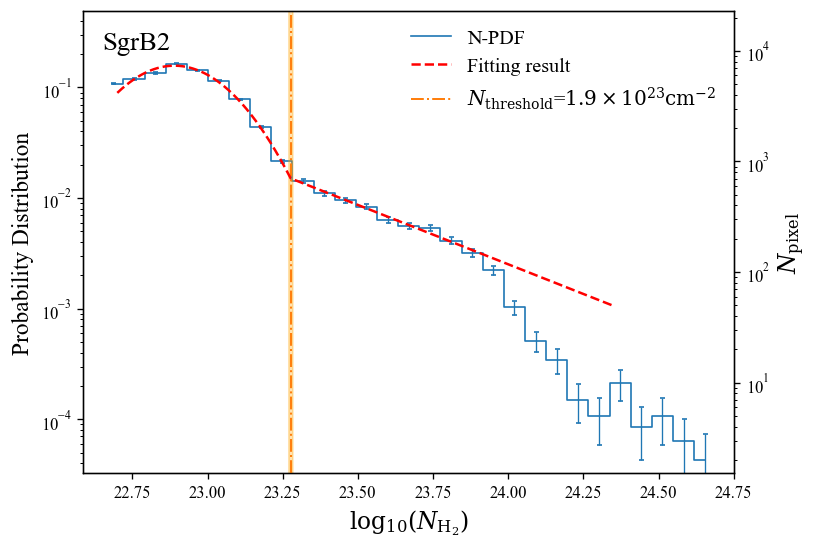

Set OBSGEO-B to    19.822811 from OBSGEO-[XYZ].
Set OBSGEO-H to     4120.022 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set OBSGEO-B to    19.822811 from OBSGEO-[XYZ].
Set OBSGEO-H to     4120.022 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


INFO: Auto-setting vmin to  2.203e+01 [aplpy.core]
INFO: Auto-setting vmax to  2.411e+01 [aplpy.core]
SgrB2 is done.


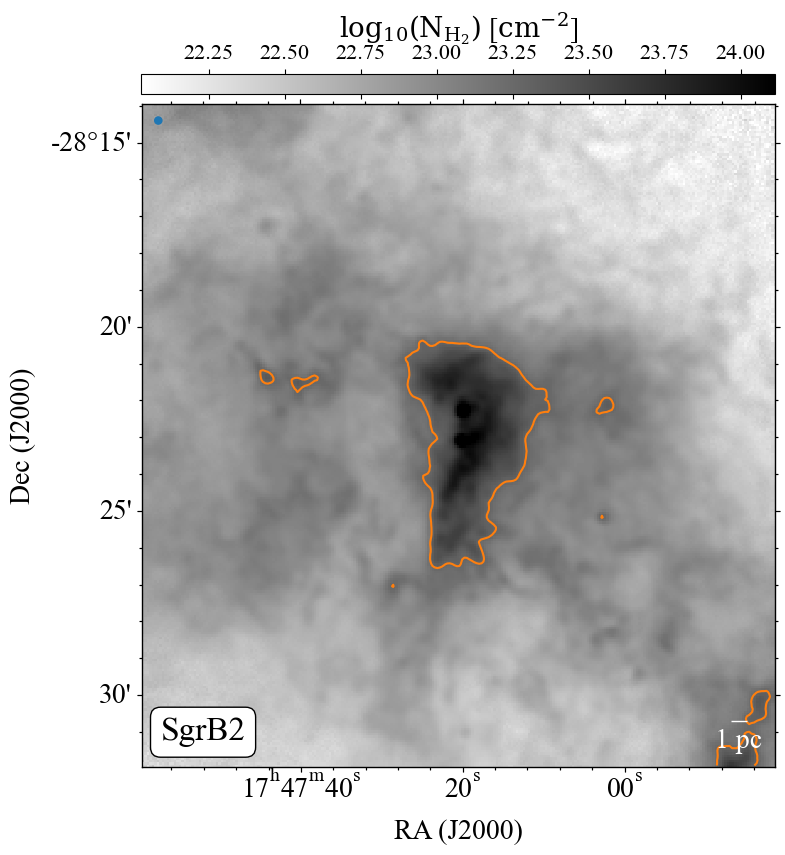

In [5]:

'''
This cell is used to calculate the mass and record the result in the excel. You can also plot the N-PDF (with fitting result), column density map, corner map here.
The plotting function does not offer many customized features. So if you’d like to fully customize your N-PDF presentation plots, it’s recommended to read data from ./NH2/, ./MCMCpara/, ./MCMCsamples/, and the Excel file, and create the plots yourself.
'''

parapathall = "./MCMCpara/"
paralist = glob.glob(f"{parapathall}/*.npy")

df = pd.read_excel(dfpath)
df = df.drop(columns="Unnamed: 0")

samplelist = glob.glob("./MCMCsamples/*.npy")
sourcenamelist = df.loc[:,"source"].tolist()

parapath = "./MCMCpara/SgrB2m_mcmcpara_22.85_23.85_LNPL.npy"
MCMCsample = "./MCMCsamples/SgrB2m_mcmcsamples_22.85_23.85_LNPL.npy"


def cornermapshow(sourcename,samplepath,savepath = None,labels = [r"$\mu$",r"$\sigma$",r"$N_{\rm threshold}$",r"$\alpha$"], scale = "eta", Nmean = None):

    flat_samples = np.load(samplepath)
    len_sample, ndim = flat_samples.shape

    errorsigma = 3
    for i in range(ndim):
        if errorsigma == 1:
            quantiles = [0.16, 0.5, 0.84]
        elif errorsigma == 2:
            quantiles = [0.023, 0.5, 0.977]
        elif errorsigma == 3:
            quantiles = [0.0013, 0.5, 0.9987]

    if scale == "eta":
        flat_samples[:,0] = np.log(10**flat_samples[:,0]/Nmean)
        flat_samples[:,2] = np.log(10**flat_samples[:,2]/Nmean)
        flat_samples[:,1] = flat_samples[:,1] * np.log(10)
    elif scale == "log10":
        pass
    elif scale == "log10forNthres":
        flat_samples[:,0] = np.log(10**flat_samples[:,0]/Nmean)
        flat_samples[:,1] = flat_samples[:,1] * np.log(10)

    # show corner map
    plt.figure(facecolor='white',figsize = (7,5),dpi=120)
    fig = corner.corner(
        flat_samples, labels=labels,
        quantiles = quantiles,
        show_titles=True,
        title_kwargs={"fontsize":12},
        label_kwargs={'fontsize':18},
        title_fmt = ".2f"
    )
    if savepath is not None:
        plt.savefig(savepath, bbox_inches='tight', format = "pdf",transparent = True)
    plt.show()

for sourcename in sourcenamelist:

    showmap = True
    shownpdf = True
    showlabel = "all"

    filepath = [x for x in pathlist if sourcename + "_" in x][0]
    parapath = [x for x in paralist if sourcename + "_" in x][0]
    samplepath = [x for x in samplelist if sourcename + "_" in x][0]

    # read parameters & preprocess
    N0 = df.loc[df["source"] == sourcename,"N0_fit"].values[0]
    N1 = df.loc[df["source"] == sourcename,"N1_fit"].values[0]
    distance = df.loc[df["source"] == sourcename,"distance"].values[0]
    Ncutoff = df.loc[df["source"] == sourcename,"Ncutoff"].values[0]
    derr = df.loc[df["source"] == sourcename,"derror"].values[0]
    map_control = df.loc[df["source"] == sourcename,["xlim1","xlim2","ylim1","ylim2"]].values[0]
    model = df.loc[df["source"] == sourcename,"model"].values[0]


    # read data and preprocess
    with fits.open(filepath) as hdulist:
        data = hdulist[0].data.copy()
        header = hdulist[0].header.copy()
    data[np.isinf(data)] = np.nan
    if np.nanmax(data) < 1e10:
        data = 10**data
    data[data < 1e20] = np.nan
    if np.isnan(Ncutoff) == False:
        data[data < 10**Ncutoff] = np.nan
    pixelsize = header["CDELT2"] * 3600
    beamsize = np.pi*36.3**2/4/np.log(2) / pixelsize**2


    # preprocess mapcontrol and derive binwidth
    data_mapcrtl = data.copy()
    if np.isnan(map_control[0]) == True:
        map_control = None
    else:
        data_mapcrtl[data_mapcrtl > 10**map_control[1]] = np.nan
    binwidth = np.log10(np.nanmax(data_mapcrtl) / np.nanmin(data_mapcrtl)) / 30

    # record Nmean
    data_mean = data.copy()
    data_mean[data_mean < 10**Ncutoff] = np.nan
    Nmean = np.nanmean(data_mean)
    Mcloud = MLE.M_calculate(data_mean,distance,pixelsize,[10**Ncutoff,np.inf])
    df.loc[df["source"] == sourcename,"Nmean"] = Nmean
    df.loc[df["source"] == sourcename,"Mcloud"] = Mcloud

    # plot NPDF
    if os.path.exists(f"./NPDF/") == False:
        os.mkdir(f"./NPDF/")
    den, bin = MLE.npdf_show(sourcename,data,binwidth,mcmcparapath = parapath,show = shownpdf,scale = "log10",samplespath = None,Nmean = Nmean,
                             savepath = f"./NPDF/{sourcename}_NPDF.pdf", plotcontrol = map_control,showlabel = showlabel)

    # read mcmc parameter cube
    mcmcpara = np.load(parapath)
    if model == "LNPL":
        Nthres = mcmcpara[2,0]
        Nthres_err1 = mcmcpara[2,1]
        Nthres_err2 = mcmcpara[2,2]
        sigma = mcmcpara[1,0]
        Nmu = mcmcpara[0,0]
        index = mcmcpara[3,0]
        sigma_err = (-mcmcpara[1,1] + mcmcpara[1,2]) / 2
        Nmu_err = (-mcmcpara[0,1] + mcmcpara[0,2]) / 2
        index_err = (-mcmcpara[3,1] + mcmcpara[3,2]) / 2
    elif model == "LN":
        sigma = mcmcpara[1,0]
        Nmu = mcmcpara[0,0]
        sigma_err = (-mcmcpara[1,1] + mcmcpara[1,2]) / 2
        Nmu_err = (-mcmcpara[0,1] + mcmcpara[0,2]) / 2
        Nthres = MLE.N_beam(data,14**2*np.pi/(header["CDELT2"]*3600)**2/np.log(2)/4, image = True)
    elif model == "PL":
        Nthres = df.loc[df["source"] == sourcename,"Nthres"].values[0]
    else:
        pass

    # record mu, eta_t, sigma_eta, alpha
    if model == "LNPL":
        mu = np.log(10**Nmu / Nmean)
        mu_err = Nmu_err * np.log(10)
        sigma_eta = sigma * np.log(10)
        sigma_eta_err = sigma_err * np.log(10)
        eta_t = np.log(10**Nthres/Nmean)
        eta_t_err_lo = np.log(10**(Nthres+Nthres_err1)/Nmean) - eta_t
        eta_t_err_up = np.log(10**(Nthres+Nthres_err2)/Nmean) - eta_t
        df.loc[df["source"] == sourcename,"mu"] = mu
        df.loc[df["source"] == sourcename,"mu_err"] = mu_err
        df.loc[df["source"] == sourcename,"sigma_eta"] = sigma_eta
        df.loc[df["source"] == sourcename,"sigma_eta_err"] = sigma_eta_err
        df.loc[df["source"] == sourcename,"eta_t"] = eta_t
        df.loc[df["source"] == sourcename,"eta_t_err_lo"] = eta_t_err_lo
        df.loc[df["source"] == sourcename,"eta_t_err_up"] = eta_t_err_up
        df.loc[df["source"] == sourcename,"alpha"] = index
        df.loc[df["source"] == sourcename,"alpha_err"] = index_err
    elif model == "PL":
        eta_t = np.log(10**Nthres/Nmean)
        df.loc[df["source"] == sourcename,"eta_t"] = eta_t
        df.loc[df["source"] == sourcename,"alpha"] = index
    elif model == "LN":
        mu = np.log(10**Nmu / Nmean)
        mu_err = Nmu_err * np.log(10)
        sigma_eta = sigma * np.log(10)
        sigma_eta_err = sigma_err * np.log(10)
        eta_t = np.log(10**Nthres/Nmean)
        df.loc[df["source"] == sourcename,"mu"] = mu
        df.loc[df["source"] == sourcename,"mu_err"] = mu_err
        df.loc[df["source"] == sourcename,"sigma_eta"] = sigma_eta
        df.loc[df["source"] == sourcename,"sigma_eta_err"] = sigma_eta_err
        df.loc[df["source"] == sourcename,"eta_t"] = eta_t

    # calculate Mln
    if model == "LNPL":
        data_1D = data.copy().ravel()
        data_1D = data_1D[~np.isnan(data_1D)]
        data_1D = data_1D[~np.isinf(data_1D)]
        den_npix = den * len(data_1D)
        den_npix1 = den_npix.copy()
        model_int, model_int_err = quad(MLE.npdf_model_log, N0, N1, args=(Nmu,sigma,Nthres,index))
        mean_model = 1 / (N1 - N0) * model_int
        den_npix[np.where(bin < N0)[0]] = np.nan
        den_npix[np.where(bin > N1)[0]] = np.nan
        mean_data = np.nanmean(den_npix)
        scale1 = mean_data / mean_model
        bin_temp = bin.copy()
        bin_temp[np.where(bin_temp < Nthres)[0]] = np.nan
        den_ln_npix = scale1*MLE.LN(bin_temp, Nmu, sigma)
        Nsum = np.nansum(den_ln_npix * 10**bin_temp)
        m_H = 1.674 * 10 ** (-27)  # in kg
        solarmass = 1.98855e30  # in kg
        pc_to_cm = 3.0857e18
        Mln = (distance * pixelsize / (3600*360) * 2 * np.pi * pc_to_cm)**2 * Nsum * 2.8 * m_H / solarmass
        df.loc[df["source"] == sourcename,"MLN"] = Mln
    else:
        pass

    # show column density map
    if showmap is True:
        hdu = fits.open(filepath)[0]
        if os.path.exists(f"./mapshow/") == False:
            os.mkdir(f"./mapshow/")
        MLE.map_show(sourcename,hdu, distance = distance, contourlist = [Nthres],savepath = f"./mapshow/{sourcename}.pdf")
    else:
        pass

    # calculate Mbound & error
    M = MLE.M_calculate(data,distance,pixelsize,[10**Nthres,np.inf])
    d_percentage = derr / distance
    M_err_d_lo = -d_percentage * M * 2
    M_err_d_up = d_percentage * M * 2

    if model == "LNPL":
        M_err_N_lo = MLE.M_calculate(data,distance,pixelsize,[10**(Nthres+Nthres_err2),np.inf]) - MLE.M_calculate(data,distance,pixelsize,[10**Nthres,np.inf])
        M_err_N_up = MLE.M_calculate(data,distance,pixelsize,[10**(Nthres+Nthres_err1),np.inf]) - MLE.M_calculate(data,distance,pixelsize,[10**Nthres,np.inf])
        Merr_lo = -np.sqrt(M_err_d_lo**2 + M_err_N_lo**2)
        Merr_up = np.sqrt(M_err_d_up**2 + M_err_N_up**2)
        df.loc[df["source"] == sourcename,"Nthres"] = Nthres
        df.loc[df["source"] == sourcename,"Nthres_err_lo"] = Nthres_err1
        df.loc[df["source"] == sourcename,"Nthres_err_up"] = Nthres_err2
        df.loc[df["source"] == sourcename,"Mbound"] = M
        df.loc[df["source"] == sourcename,"Mbound_err_lo"] = Merr_lo
        df.loc[df["source"] == sourcename,"Mbound_err_up"] = Merr_up

    elif model == "PL":
        Merr_lo = M_err_d_lo
        Merr_up = M_err_d_up
        df.loc[df["source"] == sourcename,"Mbound"] = M
        df.loc[df["source"] == sourcename,"Mbound_err_lo"] = Merr_lo
        df.loc[df["source"] == sourcename,"Mbound_err_up"] = Merr_up
    elif model == "LN":
        df.loc[df["source"] == sourcename,"Nthres"] = Nthres
        df.loc[df["source"] == sourcename,"Nbeam"] = Nthres
        df.loc[df["source"] == sourcename,"Mbound"] = M

    print(sourcename,"is done.")

df.to_excel(dfpath)

